# egui_window Demo

Showcases the lightweight HTML 'egui_window' mock utilities. These do not open a native GUI; they render styled HTML blocks inside the notebook output.

In [2]:
// Dependencies (run once).
:dep candle-notebook = { path = "../notebooks" }
use candle_notebook as nb;
use nb::{candle::Tensor, candle::Device};
use nb::egui_window;

In [3]:
// Basic text window.
egui_window::open_text("Hello Window", "This is a plain text styled block.");
// Color squares window.
egui_window::open_color_squares("Palette");

Palette

Tensor Image 
 RGB Gradient Tensor
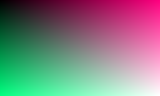

In [4]:
// Generate a tensor gradient and embed as inline image in a window.
let h = 96; let w = 160;
let mut r = Vec::with_capacity(h*w);
let mut g = Vec::with_capacity(h*w);
let mut b = Vec::with_capacity(h*w);
for y in 0..h { for x in 0..w { let fx = x as f32/(w as f32-1.0); let fy = y as f32/(h as f32-1.0); r.push(fx); g.push(fy); b.push((fx+fy)/2.0); }}
let dev = Device::Cpu;
let r = Tensor::from_vec(r, (1,h,w), &dev).unwrap();
let g = Tensor::from_vec(g, (1,h,w), &dev).unwrap();
let b = Tensor::from_vec(b, (1,h,w), &dev).unwrap();
let rgb = Tensor::cat(&[r,g,b], 0).unwrap();
let url = nb::tensor_to_png_data_url_rgb(&rgb).unwrap();
let html = format!("<p style='margin:4px 0 8px 0;font-weight:500;'>RGB Gradient Tensor</p><img style='image-rendering:pixelated;border:1px solid #333;max-width:100%;' src='{}'/>", url);
egui_window::open("Tensor Image", &html);

In [5]:
// Create multiple windows in one cell (OK).
for i in 0..3 {
  let body = format!("Window index {} -- generated at runtime.", i);
  egui_window::open_text(&format!("Batch {}", i), &body);
}

()

In [6]:
// 'Dynamic' refresh simulation: we rebuild content manually in consecutive runs.
// Execute this cell multiple times to see the counter increment.
use std::sync::atomic::{AtomicUsize, Ordering};
static COUNTER: AtomicUsize = AtomicUsize::new(0);
let n = COUNTER.fetch_add(1, Ordering::SeqCst);
let body = format!("This cell has been executed {} times.", n+1);
egui_window::open_text("Refresh Counter", &body);

Refresh Counter 
 This cell has been executed 1 times.